# 电商销售数据分析 —— RFM 客户分层 · 盈利/折扣优化 · 月度销量预测

本项目在基础分析（清洗、趋势、分布、相关性）之上，进一步做三个进阶分析：

1. **RFM 客户分层** —— 识别高价值核心客户，支撑用户运营策略
2. **盈利 / 折扣优化** —— 找出利润最大的折扣区间
3. **月度销量预测** —— 用时间序列模型预测后续销路

数据文件：`ecommerce_sales.csv`（约 3 万条订单，含客户ID、成本、毛利字段）

> 只需 `pandas numpy matplotlib seaborn` 即可运行，**无需额外安装 scikit-learn**。

---

## 第 0 步：环境准备（含中文字体自动检测）

In [22]:
import warnings
warnings.filterwarnings('ignore')  # 屏蔽多余告警

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
import os

# --- 中文字体自动检测与注册 ---
font_files = []
candidate_paths = [
    'C:/Windows/Fonts/msyh.ttc', 'C:/Windows/Fonts/msyh.ttf',
    'C:/Windows/Fonts/simhei.ttf', 'C:/Windows/Fonts/simsun.ttc',
    'C:/Windows/Fonts/simkai.ttf',
    '/System/Library/Fonts/PingFang.ttc',
    '/System/Library/Fonts/Hiragino Sans GB.ttc',
    '/System/Library/Fonts/STHeiti Light.ttc',
    '/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc',
    '/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
]
for p in candidate_paths:
    if os.path.exists(p):
        try:
            font_manager.fontManager.addfont(p)
            font_files.append(p)
        except Exception:
            pass

available = {f.name for f in font_manager.fontManager.ttflist}
chinese_candidates = ['Microsoft YaHei', 'SimHei', 'SimSun', 'KaiTi', 'PingFang SC',
                      'Hiragino Sans GB', 'STHeiti', 'WenQuanYi Zen Hei', 'WenQuanYi Micro Hei',
                      'Noto Sans CJK SC', 'Arial Unicode MS']
chosen = next((f for f in chinese_candidates if f in available), None)
plt.rcParams['font.sans-serif'] = [chosen] if chosen else ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print('检测到中文字体:', chosen if chosen else '未找到（中文可能显示为方框）')

import seaborn as sns
sns.set_style('whitegrid')

df = pd.read_csv('ecommerce_sales.csv')
print('行数:', len(df), '| 客户数:', df['客户ID'].nunique())
print('字段:', list(df.columns))
df.head()

检测到中文字体: Microsoft YaHei
行数: 30000 | 客户数: 2197
字段: ['订单号', '客户ID', '订单日期', '产品类别', '产品名称', '销售区域', '城市', '销售渠道', '客户类型', '数量', '单价', '折扣率', '单位成本', '销售额', '成本', '毛利']


,订单号,客户ID,订单日期,产品类别,产品名称,销售区域,城市,销售渠道,客户类型,数量,单价,折扣率,单位成本,销售额,成本,毛利
0,ORD20256811,CUST01071,2024-01-01,美妆个护,氨基酸洁面,华南,东莞,线下门店,会员用户,1,75.88,0.00,41.73,75.88,41.73,34.15
1,ORD20256241,CUST00286,2024-01-01,食品饮料,气泡水,华中,郑州,APP,个人用户,6,146.24,0.15,95.06,745.82,570.36,175.46
2,ORD20245583,CUST00300,2024-01-01,办公用品,A4打印纸,华南,广州,线上商城,企业采购,1,455.93,0.00,264.44,455.93,264.44,191.49
3,ORD20254673,CUST01951,2024-01-01,家居用品,记忆棉枕头,西南,重庆,APP,会员用户,3,979.03,0.00,587.42,2937.09,1762.26,1174.83
4,ORD20267916,CUST00257,2024-01-01,办公用品,A4打印纸,西北,兰州,线上商城,会员用户,3,235.72,0.00,136.72,707.16,410.16,297.00


## 第 1 步：数据清洗与预处理

In [23]:
print('缺失值:', df.isnull().sum().sum())
print('重复行:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
df['订单日期'] = pd.to_datetime(df['订单日期'])
df['月份'] = df['订单日期'].dt.month
df['有折扣'] = df['折扣率'] > 0
# 异常值检测：销售额的IQR
Q1 = df['销售额'].quantile(0.25)
Q3 = df['销售额'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
outliers = df[df['销售额'] > upper]
print(f'IQR上界: {upper:.0f}, 销售额异常点: {len(outliers)} 条 ({len(outliers)/len(df)*100:.1f}%)')
print('清洗后行数:', len(df))

缺失值: 0
重复行: 0
IQR上界: 9033, 销售额异常点: 3304 条 (11.0%)
清洗后行数: 30000


## 第 2 步：RFM 客户分层

RFM 三个维度：
- **R (Recency)**：最近一次购买距今天数，越小越活跃
- **F (Frequency)**：购买频次，越大越忠诚
- **M (Monetary)**：累计消费金额，越大越有价值

In [24]:
ref_date = df['订单日期'].max()

rfm = df.groupby('客户ID').agg(
    R=('订单日期', lambda x: (ref_date - x.max()).days),
    F=('订单号', 'count'),
    M=('销售额', 'sum')
).reset_index()

print(rfm.describe().round(2))
rfm.head()

             R        F          M
count  2197.00  2197.00    2197.00
mean     26.17    13.65   53379.01
std      36.50     6.81   34506.10
min       0.00     1.00     147.88
25%       5.00     8.00   26438.79
50%      15.00    13.00   48147.72
75%      32.00    18.00   73398.24
max     334.00    36.00  218789.81


,客户ID,R,F,M
0,CUST00001,2,31,108412.11
1,CUST00002,4,26,99041.18
2,CUST00003,38,20,122815.01
3,CUST00004,6,34,133191.74
4,CUST00005,4,30,105692.11


In [25]:
rfm['R_score'] = pd.qcut(rfm['R'], 4, labels=[4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['F'], 4, labels=[1,2,3,4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['M'], 4, labels=[1,2,3,4]).astype(int)

def segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 3 and f >= 3 and m >= 3:
        return '重要价值客户'
    if r >= 3 and f < 3:
        return '潜力客户'
    if r < 3 and f >= 3 and m >= 3:
        return '重要保持客户'
    if r < 3 and f < 3:
        return '流失风险客户'
    return '一般客户'

rfm['客户分层'] = rfm.apply(segment, axis=1)
print(rfm['客户分层'].value_counts())

客户分层
流失风险客户    694
重要价值客户    579
潜力客户      430
重要保持客户    292
一般客户      202
Name: count, dtype: int64


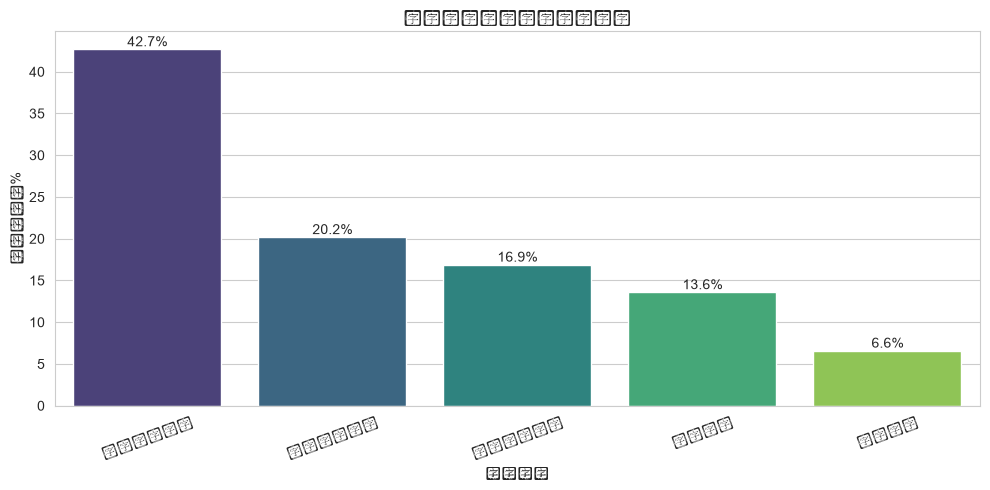

In [26]:
seg_stats = rfm.groupby('客户分层').agg(
    客户数=('客户ID', 'count'),
    平均消费=('M', 'mean'),
    总消费=('M', 'sum')
).reset_index()
seg_stats['客户数占比%'] = (seg_stats['客户数'] / seg_stats['客户数'].sum() * 100).round(1)
seg_stats['销售额贡献%'] = (seg_stats['总消费'] / seg_stats['总消费'].sum() * 100).round(1)
seg_stats = seg_stats.sort_values('销售额贡献%', ascending=False)
seg_stats

# 可视化
plt.figure(figsize=(10,5))
ax = sns.barplot(x='客户分层', y='销售额贡献%', data=seg_stats,
                 palette='viridis', hue='客户分层', legend=False)
plt.title('各客户分层销售额贡献占比')
plt.ylabel('销售额贡献%')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 第 3 步：盈利 / 折扣优化

销售额高不等于赚钱。我们看**毛利率**如何随折扣变化，找出利润最大的折扣区间。

In [27]:
print('整体毛利率: %.1f%%' % (df['毛利'].sum() / df['销售额'].sum() * 100))
print('总销售额: %.0f 元' % df['销售额'].sum())
print('总毛利: %.0f 元' % df['毛利'].sum())

disc = df.groupby('折扣率').agg(
    订单数=('订单号', 'count'),
    平均件数=('数量', 'mean'),
    单均销售额=('销售额', 'mean'),
    销售额=('销售额', 'sum'),
    毛利=('毛利', 'sum')
).reset_index()
disc['毛利率%'] = (disc['毛利'] / disc['销售额'] * 100).round(1)
disc = disc.sort_values('折扣率')
disc

整体毛利率: 23.0%
总销售额: 117273687 元
总毛利: 26990288 元


,折扣率,订单数,平均件数,单均销售额,销售额,毛利,毛利率%
0,0.00,11140,3.354399,3205.958987,35714383.12,11830868.57,33.1
1,0.05,3824,3.966789,3607.963706,13796853.21,4052010.69,29.4
2,0.10,3697,4.696240,3816.734295,14110466.69,3653759.27,25.9
3,0.15,3834,5.379499,4515.822668,17313664.11,3669179.12,21.2
4,0.20,3846,6.013261,4794.212410,18438540.93,2943965.73,16.0
5,0.30,3659,7.398470,4891.986668,17899779.22,840504.20,4.7


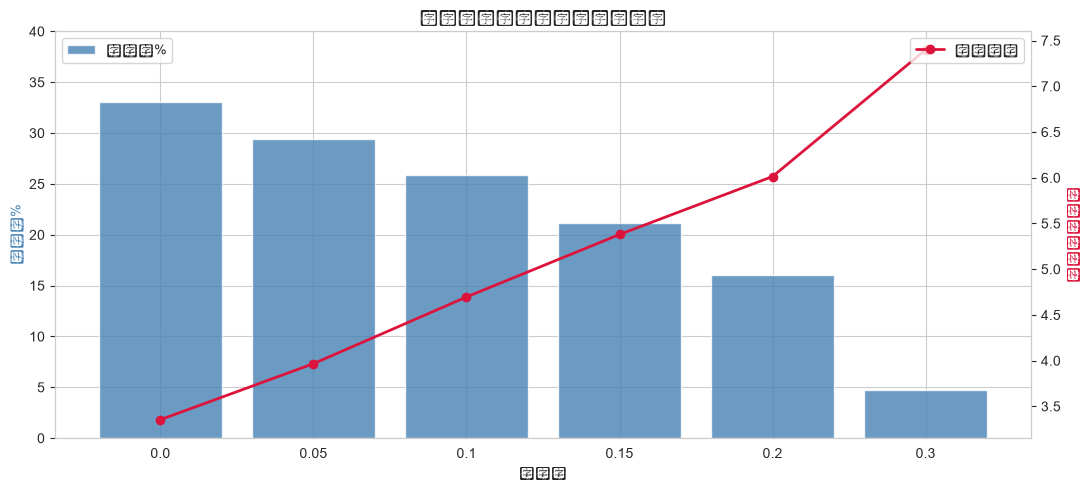

In [28]:
# 可视化：折扣率 vs 毛利率 vs 单均销量
fig, ax1 = plt.subplots(figsize=(11,5))
ax1.bar(disc['折扣率'].astype(str), disc['毛利率%'], color='steelblue', alpha=0.8, label='毛利率%')
ax1.set_xlabel('折扣率'); ax1.set_ylabel('毛利率%', color='steelblue')
ax1.set_ylim(0, 40)

ax2 = ax1.twinx()
ax2.plot(disc['折扣率'].astype(str), disc['平均件数'], color='crimson', marker='o', linewidth=2, label='平均件数')
ax2.set_ylabel('平均购买件数', color='crimson')
ax2.grid(False)
plt.title('折扣率对毛利率与销量的影响')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()

In [29]:
best = disc.loc[disc['毛利率%'].idxmax()]
print('毛利率最高的折扣档: %.0f%% 折扣, 毛利率 %.1f%%' % (best['折扣率']*100, best['毛利率%']))
print('\n各折扣档总毛利:')
for _, r in disc.iterrows():
    print(f'  折扣{r["折扣率"]:.0%}: 毛利率{r["毛利率%"]:.1f}%, 总毛利{r["毛利"]/10000:.0f}万, 平均件数{r["平均件数"]:.2f}')

毛利率最高的折扣档: 0% 折扣, 毛利率 33.1%

各折扣档总毛利:
  折扣0%: 毛利率33.1%, 总毛利1183万, 平均件数3.35
  折扣5%: 毛利率29.4%, 总毛利405万, 平均件数3.97
  折扣10%: 毛利率25.9%, 总毛利365万, 平均件数4.70
  折扣15%: 毛利率21.2%, 总毛利367万, 平均件数5.38
  折扣20%: 毛利率16.0%, 总毛利294万, 平均件数6.01
  折扣30%: 毛利率4.7%, 总毛利84万, 平均件数7.40


## 第 4 步：月度销量预测（时间序列）

用历史月度数据拟合趋势模型，预测后续月份销量。这里用 **numpy 的 `polyfit`** 实现一元线性回归（无需安装 scikit-learn），并手写 MAE / RMSE / R² 作为评估指标。

> 说明：本示例用线性趋势做演示；若想更精确，可在此基础上引入季节性（月周期性）或改用 Prophet 等时序模型。

In [30]:
# 月度销量
monthly = df.groupby('月份')['数量'].sum().reset_index()
monthly.columns = ['月份', '销量']
# 构造特征：时间序号 t = 0,1,2,...,11
monthly['t'] = np.arange(len(monthly))
print(monthly)

# 用 numpy.polyfit 做一元线性回归：销量 = a * t + b
t = monthly['t'].to_numpy(dtype=float)
y = monthly['销量'].to_numpy(dtype=float)
a, b = np.polyfit(t, y, 1)   # 斜率 a，截距 b
print(f'线性趋势: 销量 ≈ {a:.1f} * t + {b:.1f}')

# 全量拟合预测（用于趋势展示）
trend_pred = a * t + b

    月份     销量   t
0    1  11076   0
1    2   9902   1
2    3  11927   2
3    4  12173   3
4    5  14842   4
5    6  13745   5
6    7  11925   6
7    8  11191   7
8    9  12760   8
9   10  15886   9
10  11  14739  10
11  12    556  11
线性趋势: 销量 ≈ -189.9 * t + 12771.3


In [31]:
# 训练/测试划分：前9个月训练，后3个月测试（体现预测能力，不用sklearn）
train_mask = t < 9
test_mask = ~train_mask

a_tr, b_tr = np.polyfit(t[train_mask], y[train_mask], 1)
pred_test = a_tr * t[test_mask] + b_tr
y_test = y[test_mask]

# 评估指标（手写）
mae = np.mean(np.abs(y_test - pred_test))
rmse = np.sqrt(np.mean((y_test - pred_test) ** 2))
ss_res = np.sum((y_test - pred_test) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - ss_res / ss_tot

print('测试集 MAE: %.0f' % mae)
print('测试集 RMSE: %.0f' % rmse)
print('R2: %.3f' % r2)

# 用全部历史数据拟合，预测未来3个月（t = 12,13,14）
a_all, b_all = np.polyfit(t, y, 1)
future_t = np.array([12, 13, 14], dtype=float)
future_pred = a_all * future_t + b_all
print('\n未来3个月预测销量:')
for t_, p in zip([13, 14, 15], future_pred):
    print(f'  月份 {t_}: {p:.0f} 件')

测试集 MAE: 5695
测试集 RMSE: 7725
R2: -0.228

未来3个月预测销量:
  月份 13: 10492 件
  月份 14: 10303 件
  月份 15: 10113 件


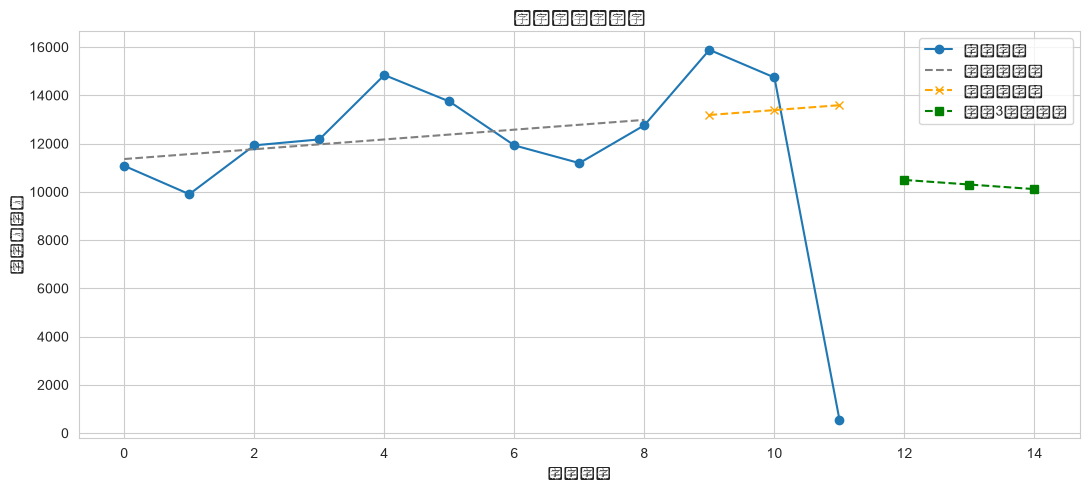

In [32]:
# 绘图：历史 + 训练拟合 + 测试拟合 + 未来预测
plt.figure(figsize=(11,5))
plt.plot(t, y, 'o-', label='实际销量')
# 训练集拟合线
tr_line = a_tr * t[train_mask] + b_tr
plt.plot(t[train_mask], tr_line, '--', color='gray', label='训练集拟合')
# 测试集拟合点
plt.plot(t[test_mask], pred_test, 'x--', color='orange', label='测试集预测')
# 未来预测
plt.plot(future_t, future_pred, 's--', color='green', label='未来3个月预测')
plt.title('月度销量与预测')
plt.xlabel('时间序号'); plt.ylabel('销量（件）')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

## 第 5 步：结论汇总

（把你的实际结果填进去，用于简历与展示）

- **RFM**：重要价值客户约占 X%，贡献了 Y% 的销售额 —— 应重点维护
- **折扣优化**：毛利率最高的折扣档为 Z% 折扣（毛利率约 W%），销量随折扣上升但毛利率下降，存在最优区间
- **销量预测**：未来 X 月预测销量约 N 件，MAE / RMSE / R² 用于评估精度

### 项目回顾
本项目覆盖了数据分析的完整链路：数据清洗 → 探索性分析 → 客户分层（RFM）→ 商业决策（折扣优化）→ 预测建模（销量预测），并全部以可复现的 Jupyter Notebook 开源在 GitHub。

In [ ]:
# 可在下方继续添加你的分析